Dataset:

https://www.kaggle.com/datasets/spandansureja/ppi-dataset/data

### README:

把從kaggle載下來的壓縮檔解壓縮，並把該資料夾放在和程式碼同層級的路徑。

### 內容：

#### Step 1

先把資料轉成Graph data，並透過ESM 2來產生node的embedding，接著建立出一個GNN當作預測網路來判斷兩個node之間是否有edge。 (後面會拿來當discriminator使用)

#### Step 2

建立一個auto regressive model，嘗試去學習如何生成一個序列，獨立訓練完之後，把她生成出來的結果一樣先經過ESM2轉成embedding，再丟到前面的GNN做判斷 ( 類似GAN中的generator和discriminator)

### Step 3(?) 沒做
把兩個模型接在一起，用GAN的方式再去做訓練

---
方向一：分子生成 (Molecule Generation)

你可以使用生成式模型來學習已知、具生物活性分子的結構模式，然後嘗試生成全新的化學化合物 。  

後續可以評估這些生成分子的有效性與新穎性，並分析它們是否可能具備預期的生物特性 。  

方向二：生物網路模擬 (Biological Network Simulation)

你可以在生物網路上訓練生成式模型，讓模型產生出新的且合理的連結或子網路結構 。  

接著分析這些合成的網路資料，觀察它是否能揭露潛在的新交互作用，或是否支持已知的生物學假設（例如：由模型提出新的蛋白質-蛋白質交互作用，並與現有的學術知識進行比對與評估） 。

---
蛋白質序列生成與資料增強 (Sequence Generation)：你可以先訓練一個生成式模型來學習資料集內蛋白質的胺基酸組成與模式，進而產生全新的蛋白質序列。接著，測試將這些合成的蛋白質序列加入訓練集中，觀察這是否能提升預測模型的效能。

新興連結生成 (Network Simulation)：利用大型基礎模型（例如蛋白質領域的語言模型 ProtBERT）將這 7 萬多筆序列轉換為特徵向量 (Embeddings)，然後在 PPI 網路上訓練生成模型，讓 AI 主動「生成（推論）」出潛在的、尚未被發現的新蛋白質交互作用連結，並評估這些新連結是否支持已知的生物學假設。

# Environemnt setup (Docker):

docker run --gpus all -itd --shm-size 128gb --name container_name -v D:/docker/your_path:/code nvcr.io/nvidia/pytorch:25.03-py3

# Requirement package:

pip install transformer
pip install umap-learn

In [1]:
# 注意：上面 requirements 寫的 `pip install transformer` 是錯的套件名 (那是別的套件)，
#       正確是 transformers。torch_geometric 在 Colab 預設也沒有，需一起裝。
!pip install -q transformers umap-learn torch_geometric kagglehub


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.26a0+c5e1555-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. p

In [2]:
# =========================================================
# 下載資料集 (kagglehub) — 不需手動上傳或掛載 Google Drive
# =========================================================
import os, glob
import kagglehub

# 下載到 Colab 雲端 VM (會自動快取，之後重跑很快)
dataset_dir = kagglehub.dataset_download("spandansureja/ppi-dataset")
print("資料集路徑:", dataset_dir)

# 自動搜尋兩個 CSV 的實際位置 (不論在哪一層子資料夾)，存成全域變數供後面使用
pos_path = glob.glob(os.path.join(dataset_dir, "**", "positive_protein_sequences.csv"), recursive=True)[0]
neg_path = glob.glob(os.path.join(dataset_dir, "**", "negative_protein_sequences.csv"), recursive=True)[0]
print("正樣本 CSV:", pos_path)
print("負樣本 CSV:", neg_path)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 47.7M/47.7M [00:03<00:00, 13.0MB/s]

Extracting files...


資料集路徑: /root/.cache/kagglehub/datasets/spandansureja/ppi-dataset/versions/1
正樣本 CSV: /root/.cache/kagglehub/datasets/spandansureja/ppi-dataset/versions/1/positive_protein_sequences.csv
負樣本 CSV: /root/.cache/kagglehub/datasets/spandansureja/ppi-dataset/versions/1/negative_protein_sequences.csv


In [3]:
import pandas as pd
import torch
from torch_geometric.data import Data
import torch_geometric.transforms as T
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score
from transformers import AutoTokenizer, EsmModel
from tqdm import tqdm
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.manifold import TSNE
import umap
from sklearn.model_selection import train_test_split

# Step 1

### 用ESM 2產生embeedding

In [4]:
def generate_esm_embeddings(seq_to_id, model, tokenizer, device):
    """
    輸入: seq_to_id (字典，紀錄 序列字串 -> 節點 ID), model
    輸出: x (Tensor，維度為 [num_nodes, feature_dim])
    """
    model.eval()

    num_nodes = len(seq_to_id)
    feature_dim = model.config.hidden_size  # 自動抓取該模型的維度 (例如 480)

    # 準備一個全為 0 的矩陣來存放結果
    x = torch.zeros((num_nodes, feature_dim))

    print(f"開始萃取 {num_nodes} 筆蛋白質序列的特徵...")

    # 不計算梯度以節省記憶體
    with torch.no_grad():
        for seq, idx in tqdm(seq_to_id.items()):
            # 2. Tokenization: 將胺基酸字串轉為模型 ID
            # 為了避免極端長度的序列撐爆記憶體，通常會設定 max_length 進行截斷
            inputs = tokenizer(seq, return_tensors="pt", truncation=True, max_length=1024)
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # 3. 通過 ESM 模型
            outputs = model(**inputs)

            # last_hidden_state 的維度是 [1, sequence_length, feature_dim]
            last_hidden_state = outputs.last_hidden_state

            # 4. Pooling (特徵池化)
            # 由於每個蛋白質長度不同，我們需要將 sequence_length 這個維度壓縮
            # 標準作法 1：取平均值 (Mean Pooling)。記得去掉頭尾的特殊 Token ([CLS], [EOS])
            seq_len = inputs['attention_mask'][0].sum().item()
            # 實際的胺基酸落在 index 1 到 seq_len-2 之間
            # 防呆：若序列為空 (只有 [CLS]+[EOS]，seq_len<=2)，取頭尾之間會是空切片，
            # mean() 會回傳 NaN。此時退回對所有有效 token 取平均。
            if seq_len > 2:
                protein_vector = last_hidden_state[0, 1:seq_len-1].mean(dim=0)
            else:
                protein_vector = last_hidden_state[0, :seq_len].mean(dim=0)

            # 5. 存入對應的 Node ID 位置，並放回 CPU
            x[idx] = protein_vector.cpu()

    return x

In [5]:
### 先載入ESM 模型
# 選擇 ESM-2 模型版本 (35M 參數版本，特徵維度 480)
model_name = "facebook/esm2_t12_35M_UR50D"

# 將模型設為評估模式，並推入 GPU (如果有)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"正在載入模型 {model_name}...")
esm_tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = EsmModel.from_pretrained(model_name).to(device)

正在載入模型 facebook/esm2_t12_35M_UR50D...


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1377.92it/s]
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 建立ppi graph

In [6]:
def build_ppi_graph(pos_csv_path, neg_csv_path, model, tokenizer, device):
    print("1. 讀取資料中...")
    pos_df = pd.read_csv(pos_csv_path)
    neg_df = pd.read_csv(neg_csv_path)

    print("2. 萃取所有獨立的節點 (蛋白質序列)...")
    # 將正樣本與負樣本中的所有序列集合起來，找出不重複的序列
    all_sequences = set(pos_df['protein_sequences_1']).union(set(pos_df['protein_sequences_2']))
    all_sequences = all_sequences.union(set(neg_df['protein_sequences_1'])).union(set(neg_df['protein_sequences_2']))

    # 建立 Sequence 到 Node ID (整數) 的映射字典
    # 注意：必須先 sorted() 再 enumerate，否則 set 的迭代順序在不同 process 之間
    # 不固定 (Python 字串 hash 隨機化)，會導致 Node ID 每次執行都不一樣、無法重現。
    all_sequences = sorted(all_sequences)
    seq_to_id = {seq: i for i, seq in enumerate(all_sequences)}
    num_nodes = len(all_sequences)
    print(f"-> 共發現 {num_nodes} 個獨立的蛋白質節點。")

    print("3. 建構邊界陣列 (Edge Index)...")
    # 處理正樣本 (有交互作用，Label = 1)
    pos_edge_1 = [seq_to_id[seq] for seq in pos_df['protein_sequences_1']]
    pos_edge_2 = [seq_to_id[seq] for seq in pos_df['protein_sequences_2']]
    pos_edges = torch.tensor([pos_edge_1, pos_edge_2], dtype=torch.long)

    # 處理負樣本 (無交互作用，Label = 0)
    neg_edge_1 = [seq_to_id[seq] for seq in neg_df['protein_sequences_1']]
    neg_edge_2 = [seq_to_id[seq] for seq in neg_df['protein_sequences_2']]
    neg_edges = torch.tensor([neg_edge_1, neg_edge_2], dtype=torch.long)

    print("4. 使用 ESM-2 建構節點真實特徵 (Node Features)...")

    x = generate_esm_embeddings(seq_to_id, model, tokenizer, device)

    return x, pos_edges, neg_edges, seq_to_id

In [7]:
# 執行轉換 (pos_path / neg_path 已在最上方的 kagglehub 設定 cell 取得)
x, pos_edges, neg_edges, sequence_mapping = build_ppi_graph(
    pos_path, neg_path, esm_model, esm_tokenizer, device
)

1. 讀取資料中...
2. 萃取所有獨立的節點 (蛋白質序列)...
-> 共發現 10344 個獨立的蛋白質節點。
3. 建構邊界陣列 (Edge Index)...
4. 使用 ESM-2 建構節點真實特徵 (Node Features)...
開始萃取 10344 筆蛋白質序列的特徵...


100%|██████████| 10344/10344 [02:09<00:00, 79.57it/s] 


In [8]:
pos = pd.read_csv(pos_path)
neg = pd.read_csv(neg_path)
print('Edges counts: ', pos.shape[0] + neg.shape[0])

Edges counts:  73110


In [9]:
def custom_link_split(x, pos_edges, neg_edges, val_ratio=0.1, test_ratio=0.2,
                      disjoint_train_ratio=0.3):
    """
    客製化的連結預測資料切分，完全保留使用者定義的正負樣本，並防止資訊洩漏。

    參數:
      x (Tensor): 節點特徵 (由 ESM 產生)
      pos_edges (Tensor): 正樣本的 edge_index，形狀為 [2, num_pos]
      neg_edges (Tensor): 負樣本的 edge_index，形狀為 [2, num_neg]
      disjoint_train_ratio (float): 訓練正樣本中，被拿來「當作預測目標 (supervision)」
          的比例；其餘的才用於 message passing。兩者互斥，避免 GNN 在訊息傳遞時
          直接看到自己要預測的那條邊 (training link leakage)。
    """

    # 1. 隨機打亂正樣本並切分
    num_pos = pos_edges.size(1)
    pos_idx = torch.randperm(num_pos)
    pos_val_end = int(val_ratio * num_pos)
    pos_test_end = pos_val_end + int(test_ratio * num_pos)

    val_pos_edges = pos_edges[:, pos_idx[:pos_val_end]]
    test_pos_edges = pos_edges[:, pos_idx[pos_val_end:pos_test_end]]
    train_pos_edges = pos_edges[:, pos_idx[pos_test_end:]]

    # 1b. 將訓練正樣本再切成「訊息傳遞用」與「監督(預測)用」兩個互斥子集
    num_train_pos = train_pos_edges.size(1)
    tp_idx = torch.randperm(num_train_pos)
    num_sup = int(disjoint_train_ratio * num_train_pos)
    sup_pos_edges = train_pos_edges[:, tp_idx[:num_sup]]   # 拿來當預測目標
    mp_pos_edges = train_pos_edges[:, tp_idx[num_sup:]]    # 拿來做 message passing

    # 2. 隨機打亂負樣本並切分
    num_neg = neg_edges.size(1)
    neg_idx = torch.randperm(num_neg)
    neg_val_end = int(val_ratio * num_neg)
    neg_test_end = neg_val_end + int(test_ratio * num_neg)

    val_neg_edges = neg_edges[:, neg_idx[:neg_val_end]]
    test_neg_edges = neg_edges[:, neg_idx[neg_val_end:neg_test_end]]
    train_neg_edges = neg_edges[:, neg_idx[neg_test_end:]]

    # --- 3. 建立 PyG Data 物件 ---

    # 【訓練集 Train Data】
    # 傳遞 (message passing): 只有 mp_pos_edges (模型藉此學習圖結構)
    train_edge_index = mp_pos_edges
    # 預測 (supervision): 與訊息傳遞「互斥」的 sup_pos_edges + Train 的負樣本
    train_label_index = torch.cat([sup_pos_edges, train_neg_edges], dim=1)
    train_label = torch.cat([torch.ones(sup_pos_edges.size(1)), torch.zeros(train_neg_edges.size(1))], dim=0)

    train_data = Data(x=x, edge_index=train_edge_index, edge_label_index=train_label_index, edge_label=train_label)

    # 【驗證集 Validation Data】
    # 傳遞: 為了防止洩漏，"只能"用全部的 Train 正樣本 (此時 Val 邊尚未被觀察到)
    val_edge_index = train_pos_edges
    # 預測: Val 的正樣本 + Val 的負樣本
    val_label_index = torch.cat([val_pos_edges, val_neg_edges], dim=1)
    val_label = torch.cat([torch.ones(val_pos_edges.size(1)), torch.zeros(val_neg_edges.size(1))], dim=0)

    val_data = Data(x=x, edge_index=val_edge_index, edge_label_index=val_label_index, edge_label=val_label)

    # 【測試集 Test Data】
    # 傳遞: 可包含 Train + Val 的正樣本 (讓測試時的圖結構更完整)
    test_edge_index = torch.cat([train_pos_edges, val_pos_edges], dim=1)
    # 預測: Test 的正樣本 + Test 的負樣本
    test_label_index = torch.cat([test_pos_edges, test_neg_edges], dim=1)
    test_label = torch.cat([torch.ones(test_pos_edges.size(1)), torch.zeros(test_neg_edges.size(1))], dim=0)

    test_data = Data(x=x, edge_index=test_edge_index, edge_label_index=test_label_index, edge_label=test_label)

    return train_data, val_data, test_data

In [10]:
train_data, val_data, test_data = custom_link_split(
    x=x,
    pos_edges=pos_edges,
    neg_edges=neg_edges,
    val_ratio=0.1,
    test_ratio=0.2
)

# 3. 將切分好的純淨資料推上 GPU/CPU
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

# 驗證一下輸出的 label 狀態
print("訓練集正樣本數:", (train_data.edge_label == 1).sum().item())
print("訓練集負樣本數:", (train_data.edge_label == 0).sum().item())

訓練集正樣本數: 7692
訓練集負樣本數: 25536


In [11]:
train_data['edge_label']
print(train_data)
print(val_data)
print(test_data)

Data(x=[10344, 480], edge_index=[2, 17949], edge_label_index=[2, 33228], edge_label=[33228])
Data(x=[10344, 480], edge_index=[2, 25641], edge_label_index=[2, 7311], edge_label=[7311])
Data(x=[10344, 480], edge_index=[2, 29304], edge_label_index=[2, 14622], edge_label=[14622])


### Define model

In [12]:
# ---------------------------------------------------------
# 1. 定義 GNN 編碼器 (Encoder)
# ---------------------------------------------------------
class GNNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # 使用 GraphSAGE，它在處理大型網路和未知節點時表現極佳
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # 第一層：聚合特徵並加上 ReLU 激活函數與 Dropout 防過擬合
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        # 第二層：輸出最終的節點 Embedding (降維)
        x = self.conv2(x, edge_index)
        return x

# ---------------------------------------------------------
# 2. 定義連結預測解碼器 (Decoder)
# ---------------------------------------------------------
class EdgeDecoder(torch.nn.Module):
    """
    用一個小型 MLP 取代原本的「原始內積」解碼器。

    原本的 (src * dst).sum() 內積在未正規化的 128 維向量上很容易產生極大的 logit，
    使 sigmoid 飽和到接近 1，導致幾乎所有配對都被預測成 ~100% (機率失去意義)。
    這裡改用對稱特徵 [src*dst, |src-dst|] 餵進 MLP：
      - 對稱 (交換 src/dst 結果不變)，符合蛋白質交互作用無方向性的特性
      - MLP 會學到較校準 (calibrated) 的分數
    """
    def __init__(self, in_channels, hidden_channels=128):
        super().__init__()
        self.lin1 = torch.nn.Linear(in_channels * 2, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, 1)

    def forward(self, z, edge_label_index):
        # z 是 Encoder 輸出的所有節點 Embedding
        # 根據 edge_label_index 抓取連線起點 (src) 與終點 (dst) 的特徵
        src = z[edge_label_index[0]]
        dst = z[edge_label_index[1]]

        # 對稱的邊特徵：element-wise 乘積 + 絕對差
        h = torch.cat([src * dst, (src - dst).abs()], dim=-1)
        h = self.lin1(h).relu()
        # 回傳原始 logit (未過 sigmoid)，搭配 BCEWithLogitsLoss
        return self.lin2(h).squeeze(-1)

# ---------------------------------------------------------
# 3. 組合出最終模型
# ---------------------------------------------------------
class LinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.encoder = GNNEncoder(in_channels, hidden_channels, out_channels)
        self.decoder = EdgeDecoder(out_channels)

    def forward(self, x, edge_index, edge_label_index):
        # 1. 透過 Encoder 取得每個節點的新特徵 z
        z = self.encoder(x, edge_index)
        # 2. 透過 Decoder 預測標籤邊的連接機率分數
        return self.decoder(z, edge_label_index)

In [13]:
def train_and_validate(model, optimizer, criterion, train_data, val_data, epochs=100):
    print("🚀 開始訓練模型...")
    best_val_auc = 0.0

    # 建立一個字典來儲存訓練歷程
    history = {
        'train_loss': [],
        'val_epochs': [], # 因為 validation 不是每個 epoch 都做，所以要另外記 epoch
        'val_auc': []
    }

    for epoch in tqdm(range(1, epochs + 1)):
        # --- [訓練階段] ---
        model.train()
        optimizer.zero_grad()

        out = model(train_data.x, train_data.edge_index, train_data.edge_label_index)
        loss = criterion(out, train_data.edge_label.float())

        loss.backward()
        optimizer.step()

        # 紀錄每個 epoch 的 Train Loss
        history['train_loss'].append(loss.item())

        # --- [驗證階段] ---
        if epoch % 10 == 0:
            val_auc = evaluate_model(model, val_data)
            print(f'Epoch: {epoch:03d} | Train Loss: {loss.item():.4f} | Validation AUC: {val_auc:.4f}')

            # 紀錄驗證集的 AUC 分數與對應的 epoch
            history['val_epochs'].append(epoch)
            history['val_auc'].append(val_auc)

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                torch.save(model.state_dict(), 'best_model.pth')

    print("✅ 訓練階段結束！")
    # 將 history 一併回傳
    return model, history

@torch.no_grad()
def evaluate_model(model, data):
    model.eval()
    out = model(data.x, data.edge_index, data.edge_label_index)
    pred = torch.sigmoid(out).cpu().numpy()
    target = data.edge_label.cpu().numpy()
    return roc_auc_score(target, pred)

In [14]:
def plot_training_history(history):
    # 設定畫布大小 (寬度 12, 高度 5)
    plt.figure(figsize=(12, 5))

    # --- 繪製 Training Loss 曲線 (左圖) ---
    plt.subplot(1, 2, 1)
    # x 軸為 1~epochs
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (BCE)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # --- 繪製 Validation AUC 曲線 (右圖) ---
    plt.subplot(1, 2, 2)
    plt.plot(history['val_epochs'], history['val_auc'], label='Validation AUC', color='orange', marker='o')
    plt.title('Validation AUC Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('AUC Score')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # 自動調整排版並顯示
    plt.tight_layout()
    plt.show()

In [15]:
# in_channels 必須對應你 ESM-2 的輸出維度 (480)
gnn_model = LinkPredictor(in_channels=480, hidden_channels=256, out_channels=128).to(device)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=5e-4)

# 因為解碼器輸出的是原始內積值，所以使用 BCEWithLogitsLoss (內部自帶 Sigmoid)
criterion = torch.nn.BCEWithLogitsLoss()

🚀 開始訓練模型...


  5%|▍         | 23/500 [00:00<00:10, 46.90it/s]

Epoch: 010 | Train Loss: 0.5587 | Validation AUC: 0.7823
Epoch: 020 | Train Loss: 0.4501 | Validation AUC: 0.7876
Epoch: 030 | Train Loss: 0.3631 | Validation AUC: 0.8812


 12%|█▏        | 61/500 [00:00<00:03, 114.06it/s]

Epoch: 040 | Train Loss: 0.3390 | Validation AUC: 0.8988
Epoch: 050 | Train Loss: 0.3066 | Validation AUC: 0.9167
Epoch: 060 | Train Loss: 0.2865 | Validation AUC: 0.9306
Epoch: 070 | Train Loss: 0.2612 | Validation AUC: 0.9396
Epoch: 080 | Train Loss: 0.2479 | Validation AUC: 0.9462
Epoch: 090 | Train Loss: 0.2346 | Validation AUC: 0.9518


...

Epoch: 320 | Train Loss: 0.0923 | Validation AUC: 0.9847
Epoch: 330 | Train Loss: 0.0912 | Validation AUC: 0.9849
Epoch: 340 | Train Loss: 0.0886 | Validation AUC: 0.9850
Epoch: 350 | Train Loss: 0.0845 | Validation AUC: 0.9852
Epoch: 360 | Train Loss: 0.0891 | Validation AUC: 0.9853
Epoch: 370 | Train Loss: 0.0849 | Validation AUC: 0.9853


 88%|████████▊ | 441/500 [00:02<00:00, 259.91it/s]

Epoch: 380 | Train Loss: 0.0791 | Validation AUC: 0.9852
Epoch: 390 | Train Loss: 0.0777 | Validation AUC: 0.9854
Epoch: 400 | Train Loss: 0.0756 | Validation AUC: 0.9852
Epoch: 410 | Train Loss: 0.0735 | Validation AUC: 0.9853
Epoch: 420 | Train Loss: 0.0713 | Validation AUC: 0.9850
Epoch: 430 | Train Loss: 0.0758 | Validation AUC: 0.9855
Epoch: 440 | Train Loss: 0.0707 | Validation AUC: 0.9857
Epoch: 450 | Train Loss: 0.0680 | Validation AUC: 0.9859


100%|██████████| 500/500 [00:02<00:00, 187.93it/s]


Epoch: 460 | Train Loss: 0.0695 | Validation AUC: 0.9857
Epoch: 470 | Train Loss: 0.0694 | Validation AUC: 0.9857
Epoch: 480 | Train Loss: 0.0640 | Validation AUC: 0.9851
Epoch: 490 | Train Loss: 0.0646 | Validation AUC: 0.9858
Epoch: 500 | Train Loss: 0.0641 | Validation AUC: 0.9859
✅ 訓練階段結束！

🎉 最終盲測結果! Final Test AUC: 0.9840


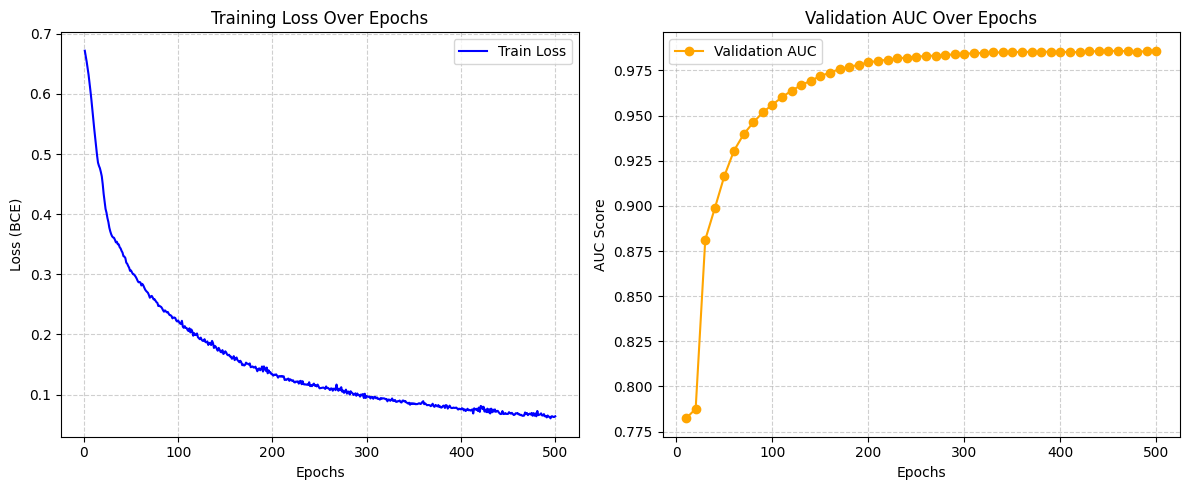

In [16]:
# ==========================================
# 3. 實際呼叫方式
# ==========================================
# 假設 model, optimizer, criterion, train_data, val_data, test_data 都已定義好
trained_model, training_history  = train_and_validate(gnn_model, optimizer, criterion, train_data, val_data, epochs=500)

# 重要：train_and_validate 只在「驗證 AUC 創新高」時把權重存到 best_model.pth，
# 但回傳的 trained_model 是「最後一個 epoch」的權重。為了讓盲測結果對應到實際會部署
# 的最佳檢查點，這裡先把 best_model.pth 載回來再做測試。
trained_model.load_state_dict(torch.load('best_model.pth', map_location=device))

final_test_auc = evaluate_model(trained_model, test_data)
print(f'\n================================')
print(f'🎉 最終盲測結果! Final Test AUC: {final_test_auc:.4f}')
print(f'================================')


# 呼叫畫圖函式
plot_training_history(training_history)

### t-SNE ( Local Structure ) vs. UMAP ( Gloval Structure )

In [17]:
@torch.no_grad()
def plot_top_predictions(model, data, top_k=50):
    model.eval()

    # 1. 取得測試集上的預測機率
    out = model(data.x, data.edge_index, data.edge_label_index)
    probs = torch.sigmoid(out).cpu().numpy()

    # 2. 取得真實標籤與對應的節點 ID
    labels = data.edge_label.cpu().numpy()
    edges = data.edge_label_index.cpu().numpy()

    # 3. 找出「模型預測機率最高」的前 top_k 條邊的索引
    # np.argsort 會從小排到大，所以取倒數 top_k 個，再反轉順序
    top_indices = np.argsort(probs)[-top_k:][::-1]

    # 4. 建立 NetworkX 畫布
    G = nx.Graph()

    # 將這些高信心度的邊加入圖中
    for idx in top_indices:
        src = edges[0, idx]
        dst = edges[1, idx]
        prob = probs[idx]
        is_true = labels[idx] == 1.0  # 檢查這個預測是不是真的答對了

        # 設定邊的顏色：預測正確標綠色，預測錯誤(False Positive)標紅色
        edge_color = 'green' if is_true else 'red'

        G.add_edge(src, dst, weight=prob, color=edge_color)

    # 5. 開始繪圖
    plt.figure(figsize=(10, 8))

    # 增加 k 值把節點推開，增加迭代次數
    pos = nx.spring_layout(G, k=0.8, iterations=100, seed=42)

    # 取得剛才設定好的邊顏色
    edge_colors = [G[u][v]['color'] for u, v in G.edges()]
    # 讓機率越高的邊越粗
    edge_widths = [G[u][v]['weight'] * 3 for u, v in G.edges()]

    # 畫節點與邊
    # 縮小節點，拔掉文字標籤 (拿掉 nx.draw_networkx_labels)
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=100, edgecolors='black')
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.8)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

    plt.title(f"Top {top_k} Predicted Protein Interactions", fontsize=16)

    # 加上簡單的圖例說明
    import matplotlib.lines as mlines
    green_line = mlines.Line2D([], [], color='green', linewidth=2, label='True Positive (Correct)')
    red_line = mlines.Line2D([], [], color='red', linewidth=2, label='False Positive (Wrong)')
    plt.legend(handles=[green_line, red_line], loc='best')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

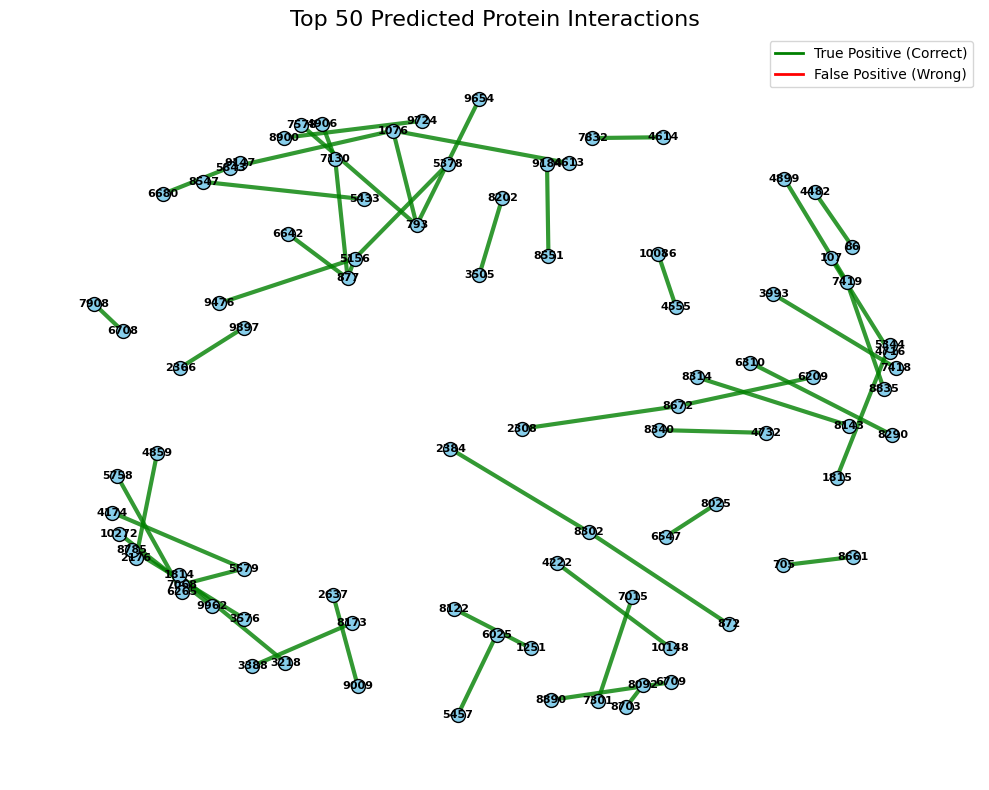

In [18]:
# 執行繪圖 (假設 trained_model 和 test_data 已經準備好)
plot_top_predictions(trained_model, test_data, top_k=50)

In [19]:
@torch.no_grad()
def plot_tsne_edge_embeddings(model, data, num_samples=2000, method = "UMAP"):
    """
    對測試集的邊特徵進行 t-SNE 降維並視覺化
    """
    model.eval()

    # 1. 透過 Encoder 取得所有節點的 128 維潛在特徵
    z = model.encoder(data.x, data.edge_index)

    # 2. 取得預測目標的邊與真實標籤
    edges = data.edge_label_index
    labels = data.edge_label.cpu().numpy()

    # 3. 建構邊的特徵 (Edge Features)
    # 我們的 Decoder 是計算內積，這裡我們可以將起點與終點的向量相乘來代表這條邊
    src = z[edges[0]]
    dst = z[edges[1]]
    edge_features = (src * dst).cpu().numpy()

    # 4. 隨機抽樣
    # 測試集通常有破萬條邊，全跑 t-SNE 會太久且圖太擠，我們隨機抽 2000 點
    np.random.seed(42)
    indices = np.random.choice(len(labels), size=min(num_samples, len(labels)), replace=False)
    sampled_features = edge_features[indices]
    sampled_labels = labels[indices]

    # 5. 執行 t-SNE 降維 (從 128 維降到 2 維)
    # perplexity 影響局部流形的權重，30~50 是常規設定
    if method == "UMAP":
        print("正在計算 UMAP...")
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        reduced_features = reducer.fit_transform(sampled_features)
    elif method == "t-SNE":
        print("正在計算 t-SNE，這可能需要幾十秒鐘...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        reduced_features = tsne.fit_transform(sampled_features)
    else:
        print("Error!!!")

    # 6. 繪製散佈圖
    plt.figure(figsize=(10, 8))

    # 畫負樣本 (Label 0: No Interaction)
    plt.scatter(reduced_features[sampled_labels == 0, 0],
                reduced_features[sampled_labels == 0, 1],
                c='tomato', label='No Interaction', alpha=0.6, s=15, edgecolors='none')

    # 畫正樣本 (Label 1: Interaction)
    plt.scatter(reduced_features[sampled_labels == 1, 0],
                reduced_features[sampled_labels == 1, 1],
                c='mediumseagreen', label='Interaction', alpha=0.6, s=15, edgecolors='none')

    plt.title(f'{method} Visualization of Protein Pair Embeddings', fontsize=16)
    plt.legend(markerscale=3) # 把圖例的點放大一點方便看
    plt.axis('off')
    plt.tight_layout()
    plt.show()

正在計算 t-SNE，這可能需要幾十秒鐘...


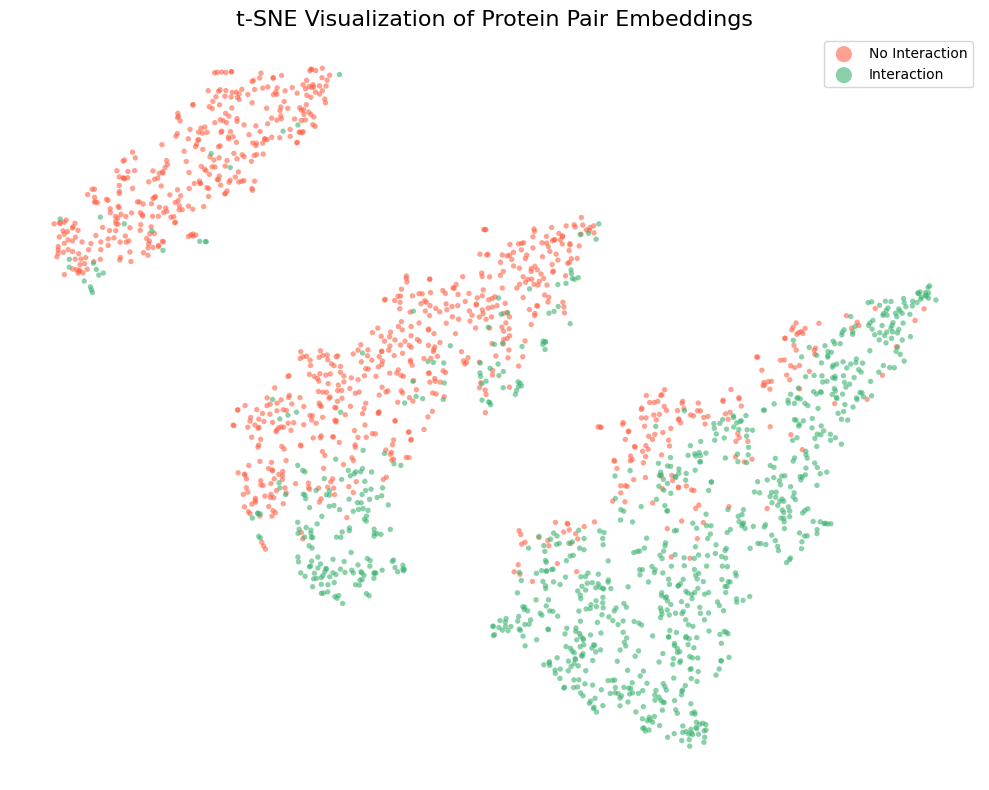

In [20]:
# 呼叫方式 (假設 trained_model 和 test_data 已準備好)：
plot_tsne_edge_embeddings(trained_model, test_data, num_samples=2000, method = "t-SNE")

正在計算 UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


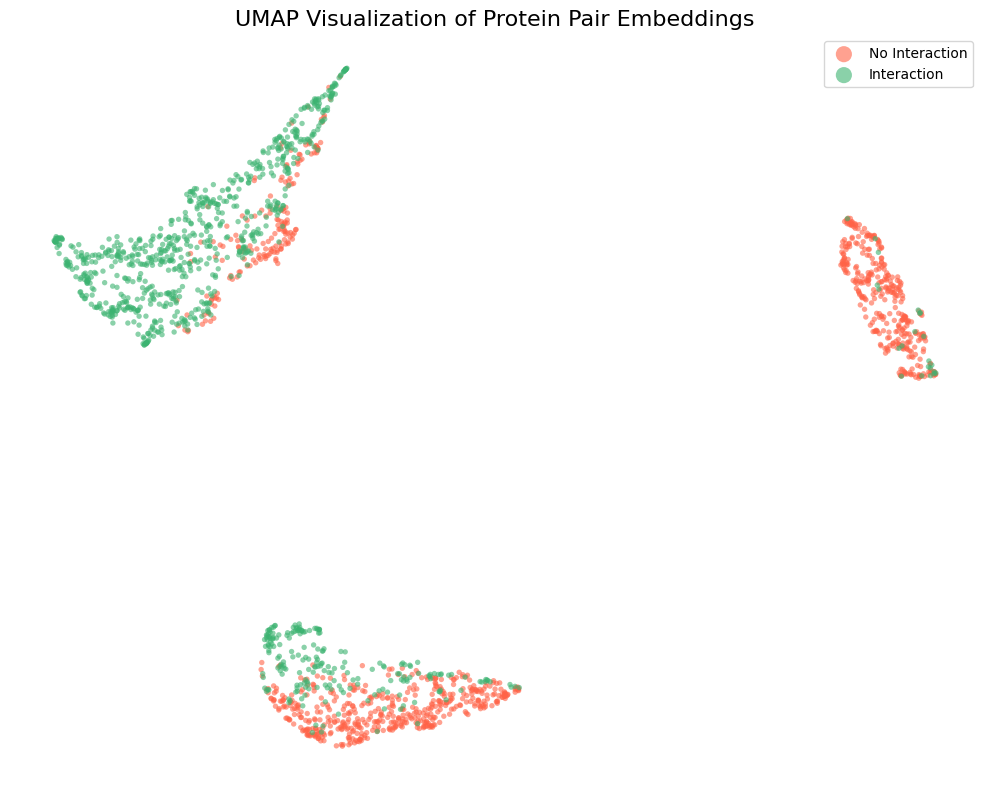

In [21]:
# 替換掉原本的 TSNE 宣告
plot_tsne_edge_embeddings(trained_model, test_data, num_samples=2000, method = "UMAP")

# Step 2

### Generate a new node ( protein sequence )
#### Train a generator to generate sequence

#### ESM2 transform

### GNN evaluation

Build Amino acid dictionary

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 1. 定義 20 種常見胺基酸與特殊 Token
amino_acids = ['_','<bos>', '<eos>', 'A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
char_to_idx = {char: idx for idx, char in enumerate(amino_acids)}
idx_to_char = {idx: char for idx, char in enumerate(amino_acids)}
vocab_size = len(amino_acids)

# 2. 定義 PyTorch Dataset
class ProteinSeqDataset(Dataset):
    def __init__(self, sequences, max_length=256):
        self.sequences = sequences
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        # 截斷過長的序列，留空間給 <bos> 和 <eos>
        seq = seq[:self.max_length - 2]

        # 組裝序列： <bos> + 胺基酸序列 + <eos>
        full_seq = ['<bos>'] + list(seq) + ['<eos>']
        numerical_seq = [char_to_idx.get(c, 0) for c in full_seq] # 若有未知字母用 '_'

        # Padding 到相同長度
        pad_len = self.max_length - len(numerical_seq)
        numerical_seq += [char_to_idx['_']] * pad_len

        # 自迴歸的輸入與輸出對齊：Input 是 0 到 N-1，Target 是 1 到 N
        token_tensor = torch.tensor(numerical_seq, dtype=torch.long)
        x = token_tensor[:-1]
        y = token_tensor[1:]
        return x, y

Auto regressive Transformer model

In [23]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)
    def forward(self, x):
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        return x + self.pe(positions)

class ProteinMiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.3):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = PositionalEncoding(d_model)

        # 建立 Transformer 層（顯式加上 dropout 參數）
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True,
            activation='gelu',
            dropout=dropout  # <--- 💡 關鍵：提高這裡的比例來對抗過擬合
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 最終輸出的 Language Modeling Head
        self.ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        sz = x.size(1)
        mask = nn.Transformer.generate_square_subsequent_mask(sz, device=x.device)

        out = self.token_emb(x)
        out = self.pos_emb(out)

        out = self.transformer(out, mask=mask, is_causal=True)
        out = self.ln(out)
        logits = self.lm_head(out)
        return logits

Train model

In [24]:
# =========================================================
# 1. 準備資料集 (使用先前定義的 Dataset 與字典)
# =========================================================
def prepare_sequences_from_csv(pos_csv, neg_csv):
    """從你的兩個 CSV 檔案中萃取出所有真實的蛋白質序列"""
    pos_df = pd.read_csv(pos_csv)
    neg_df = pd.read_csv(neg_csv)

    # 將所有欄位的序列取出來，去重覆並轉成 List
    all_seqs = set(pos_df['protein_sequences_1']).union(set(pos_df['protein_sequences_2']))
    all_seqs = all_seqs.union(set(neg_df['protein_sequences_1'])).union(set(neg_df['protein_sequences_2']))
    return list(all_seqs)

# 確保先前的字典與 Dataset 已經宣告
# (這裡直接實例化 DataLoader)
def get_dataloader(sequences, batch_size=64, max_length=128, drop_last=True):
    dataset = ProteinSeqDataset(sequences, max_length=max_length)
    # shuffle=True 確保每個 epoch 的資料順序都是隨機打亂的
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=drop_last)
    return dataloader

# =========================================================
# 2. 封裝：Generator 訓練主函式
# =========================================================
def train_generator(model, train_loader, val_loader, optimizer, criterion, epochs=20, device='cpu'):
    print(f"🚀 開始訓練 Generator (使用裝置: {device})...")

    history = {
        'train_loss': [],
        'val_loss': []
    }

    # 紀錄最佳的驗證損失 (初始設為無限大)
    best_val_loss = float('inf')

    for epoch in range(1, epochs + 1):
        # ==========================================
        # 階段一：訓練 (Training Phase)
        # ==========================================
        model.train()
        train_epoch_loss = 0.0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs:02d} [Train]")
        for batch_x, batch_y in train_bar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out.view(-1, vocab_size), batch_y.view(-1))
            loss.backward()

            # 梯度裁剪防止爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_epoch_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = train_epoch_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # ==========================================
        # 階段二：驗證 (Validation Phase)
        # ==========================================
        model.eval()
        val_epoch_loss = 0.0

        # 驗證時關閉梯度追蹤以節省記憶體與加快運算
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                out = model(batch_x)
                loss = criterion(out.view(-1, vocab_size), batch_y.view(-1))
                val_epoch_loss += loss.item()

        avg_val_loss = val_epoch_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)

        # 輸出目前 Epoch 的總結
        print(f"📢 Epoch {epoch:02d} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # 檢查是否為歷史最佳模型 (驗證損失越低越好)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_generator.pth')
            print(f"🔥 發現更好的模型！已儲存至 best_generator.pth")

        print("-" * 50)

    print("✅ Generator 訓練結束！")
    return model, history

In [25]:
def plot_generator_history(history):
    plt.figure(figsize=(8, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.plot(epochs_range, history['train_loss'], color='purple', label='Train Loss', linestyle='-')
    plt.plot(epochs_range, history['val_loss'], color='teal', label='Val Loss', linestyle='--')

    plt.title('Generator Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Cross Entropy Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

In [26]:
# =========================================================
# 3. 實際執行流程範例
# =========================================================

# 設定超參數
BATCH_SIZE = 64
MAX_SEQ_LEN = 128  # 序列長度，小的 Transformer 設 128 運算較快
EPOCHS = 50
LR = 5e-4

# 1. 讀取所有不重複的序列 (pos_path / neg_path 來自最上方的 kagglehub 設定 cell)
sequences = prepare_sequences_from_csv(pos_path, neg_path)

# 2. 切分資料集 (90% 訓練, 10% 驗證)
train_seqs, val_seqs = train_test_split(sequences, test_size=0.1, random_state=42)
print(f"總序列數: {len(sequences)} | 訓練集: {len(train_seqs)} | 驗證集: {len(val_seqs)}")

train_loader = get_dataloader(train_seqs, batch_size=BATCH_SIZE, max_length=MAX_SEQ_LEN, drop_last=True)
val_loader = get_dataloader(val_seqs, batch_size=BATCH_SIZE, max_length=MAX_SEQ_LEN, drop_last=False)

# 2. 初始化模型、優化器與損失函數
generator = ProteinMiniGPT(vocab_size=vocab_size, d_model=128, nhead=4, num_layers=3).to(device)

# 關鍵：設定 ignore_index，讓模型自動跳過對 Padding 字母 '_' 的 Loss 計算
criterion = nn.CrossEntropyLoss(ignore_index=char_to_idx['_'])

# 訓練語言模型通常推薦使用 AdamW
optimizer = torch.optim.AdamW(generator.parameters(), lr=LR, weight_decay=0.01)

# 3. 呼叫訓練
trained_generator, gen_history = train_generator(
        model=generator,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=EPOCHS,
        device=device
    )

總序列數: 10344 | 訓練集: 9309 | 驗證集: 1035
🚀 開始訓練 Generator (使用裝置: cuda)...


Epoch 01/50 [Train]: 100%|██████████| 145/145 [00:02<00:00, 66.64it/s, loss=2.8165]


📢 Epoch 01 -> Train Loss: 2.8569 | Val Loss: 2.8056
🔥 發現更好的模型！已儲存至 best_generator.pth
--------------------------------------------------


Epoch 02/50 [Train]: 100%|██████████| 145/145 [00:01<00:00, 86.86it/s, loss=2.8022]


📢 Epoch 02 -> Train Loss: 2.8083 | Val Loss: 2.7910
🔥 發現更好的模型！已儲存至 best_generator.pth
--------------------------------------------------


...

📢 Epoch 48 -> Train Loss: 2.7444 | Val Loss: 2.7628
--------------------------------------------------


Epoch 49/50 [Train]: 100%|██████████| 145/145 [00:01<00:00, 75.04it/s, loss=2.7719]


📢 Epoch 49 -> Train Loss: 2.7441 | Val Loss: 2.7637
--------------------------------------------------


Epoch 50/50 [Train]: 100%|██████████| 145/145 [00:02<00:00, 69.16it/s, loss=2.7530]


📢 Epoch 50 -> Train Loss: 2.7436 | Val Loss: 2.7608
--------------------------------------------------
✅ Generator 訓練結束！


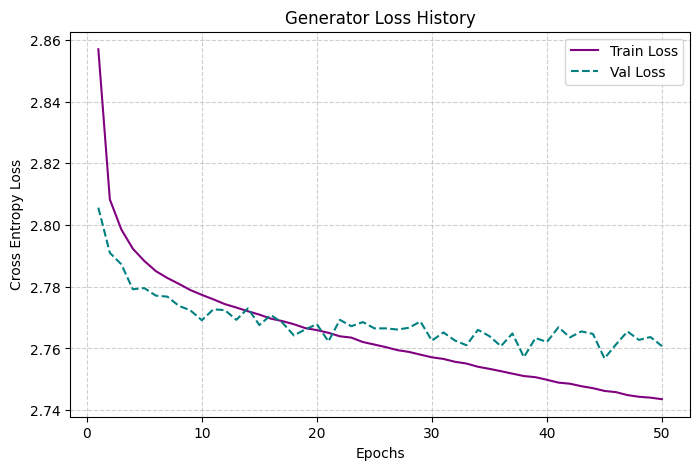

In [27]:
plot_generator_history(gen_history)

Generate new sequence

In [28]:
@torch.no_grad()
def generate_new_protein(model, max_len=100, temperature=0.8, top_k=5):
    model.eval()
    device = next(model.parameters()).device

    # 不允許被生成出來的特殊 token：padding '_' 與 起始符 '<bos>'
    # (這些不是胺基酸，若被採樣到會污染序列字串並讓 ESM 拿到無效輸入)
    forbidden_ids = [char_to_idx['_'], char_to_idx['<bos>']]

    # 1. 初始狀態只有一個啟動 Token: <bos>
    current_seq = [char_to_idx['<bos>']]
    input_tensor = torch.tensor([current_seq], dtype=torch.long, device=device)

    for _ in range(max_len):
        # 2. 讓模型預測下一個字的 Logits
        logits = model(input_tensor)
        next_token_logits = logits[0, -1, :] / temperature # 調整溫度

        # 2.5 封鎖非胺基酸的特殊 token，避免被採樣
        for fid in forbidden_ids:
            next_token_logits[fid] = -float('Inf')

        # 3. Top-k 採樣防瞎猜：只保留機率最高的前 k 個字，其餘設為負無窮大
        v, _ = torch.topk(next_token_logits, top_k)
        next_token_logits[next_token_logits < v[-1]] = -float('Inf')

        # 4. 轉成機率分佈並抽樣
        probs = F.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1).item()

        # 5. 如果抽到結束 Token，就停止生成
        if next_token == char_to_idx['<eos>']:
            break

        current_seq.append(next_token)
        input_tensor = torch.tensor([current_seq], dtype=torch.long, device=device)

    # 6. 將數字 ID 陣列轉回胺基酸字串
    generated_amino_acids = [idx_to_char[idx] for idx in current_seq[1:]] # 跳過 <bos>
    return "".join(generated_amino_acids)

In [29]:
def run_end_to_end_pipeline(original_graph_data, target_node_id=0,
                            ESM_model = esm_model,tokenizer = esm_tokenizer,
                            generator_weight = 'best_generator.pth', gnn_weight = 'best_model.pth'):
    print("=== 🌟 啟動 GenAI + Bio-Informatics 終極串聯管線 ===")

    # ---------------------------------------------------------
    # 載入預訓練好的 Generator 與 GNN 裁判
    # ---------------------------------------------------------
    print("\n正在載入 AI 模型權重...")

    # 初始化並載入 Mini-GPT (Generator)
    generator = ProteinMiniGPT(vocab_size=vocab_size, d_model=128, nhead=4, num_layers=3).to(device)
    generator.load_state_dict(torch.load(generator_weight, map_location=device))

    # 初始化並載入 GNN (Discriminator / Evaluator)
    gnn_model = LinkPredictor(in_channels=480, hidden_channels=256, out_channels=128).to(device)
    gnn_model.load_state_dict(torch.load(gnn_weight, map_location=device))

    # ---------------------------------------------------------
    #  Generator 製造全新蛋白質序列
    # ---------------------------------------------------------
    print("\nGenerator 開始執行自迴歸序列生成 (文字接龍)...")
    # 呼叫我們先前寫好的 Top-k 採樣生成函式
    new_sequence = generate_new_protein(generator, max_len=100, temperature=0.8, top_k=5)
    print(f"👉 成功創造全新蛋白質序列:\n{new_sequence}")

    # 防呆：若生成出空序列就直接中止，否則後面 ESM pooling 會得到 NaN
    if len(new_sequence) == 0:
        print("⚠️ Generator 產生了空序列，無法評估，提前結束。")
        return



    with torch.no_grad():
        inputs = tokenizer(new_sequence, return_tensors="pt", truncation=True, max_length=1024)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = ESM_model(**inputs)

        # Mean Pooling 取得 480 維向量
        seq_len = inputs['attention_mask'][0].sum().item()
        # 防呆：序列太短 (只剩特殊 token) 時改對全部有效 token 取平均，避免空切片產生 NaN
        if seq_len > 2:
            new_node_feature = outputs.last_hidden_state[0, 1:seq_len-1].mean(dim=0) # shape: [480]
        else:
            new_node_feature = outputs.last_hidden_state[0, :seq_len].mean(dim=0)

    # ---------------------------------------------------------
    # 動態圖形結構重組 (Graph Manipulation)
    # ---------------------------------------------------------
    print("\n將新節點動態插入原始 PyG Graph 拓撲中...")
    original_x = original_graph_data.x.to(device) # shape: [10344, 480]

    # 將新節點的特徵拼接到原本的特徵矩陣尾巴
    # new_node_feature.unsqueeze(0) 的 shape 會變成 [1, 480]
    x_extended = torch.cat([original_x, new_node_feature.unsqueeze(0)], dim=0) # shape: [10345, 480]
    new_node_id = x_extended.size(0) - 1 # 新節點的 ID 就是 10344

    # 建立測試邊 (Edge Label Index)：[新節點 ID, 目標標靶 ID]
    # 我們想預測新創的蛋白質 (10344) 與你指定的 target_node_id 是否會互動
    test_edge_index = torch.tensor([[new_node_id], [target_node_id]], dtype=torch.long, device=device)

    # ---------------------------------------------------------
    # Step 5. GNN 裁判進行最後判分
    # ---------------------------------------------------------
    print(f"\nGNN 裁判開始評估新蛋白質與節點(ID: {target_node_id}) 的互動機率...")
    gnn_model.eval()
    with torch.no_grad():
        # 傳入擴展後的 x_extended，但 edge_index 維持原始拓撲（因為新節點在圖中尚未有既定連線）
        out = gnn_model(x_extended, original_graph_data.edge_index.to(device), test_edge_index)
        interaction_prob = torch.sigmoid(out).item()

    print(f"\n==================================================")
    print(f"🎉 評估完成！")
    print(f"AI 預測該全新序列與目標標靶的交互作用機率為: {interaction_prob * 100:.2f}%")
    if interaction_prob > 0.75:
        print("🔥 結論：這是一個極具潛力的 De Novo 蛋白質設計成果！")
    else:
        print("🧊 結論：結合力較弱，Generator 還需繼續努力。")
    print(f"==================================================")

inference_graph = Data(x=x, edge_index=pos_edges)

# 確保圖形資料也在對應的裝置上
inference_graph = inference_graph.to(device)


# 執行管線 (假設你原本讀取的原始 ppi_graph 還在記憶體中)
run_end_to_end_pipeline(inference_graph, target_node_id=809,
                        ESM_model = esm_model,tokenizer = esm_tokenizer,
                        generator_weight = 'best_generator.pth', gnn_weight = 'best_model.pth')

=== 🌟 啟動 GenAI + Bio-Informatics 終極串聯管線 ===

正在載入 AI 模型權重...

Generator 開始執行自迴歸序列生成 (文字接龍)...
👉 成功創造全新蛋白質序列:
MAGLLPLPLLAVLLALAVGLAAPARAPPGGPPAPGPGPGPPPPGPPAPGGPGGGPGAPPGPPGPGAPAPGPGGPGGPGSGAPGPGGLGPALGGAGAGPGP

將新節點動態插入原始 PyG Graph 拓撲中...

GNN 裁判開始評估新蛋白質與節點(ID: 809) 的互動機率...

🎉 評估完成！
AI 預測該全新序列與目標標靶的交互作用機率為: 97.76%
🔥 結論：這是一個極具潛力的 De Novo 蛋白質設計成果！


# Step 3：De novo interactor design（生成 → 篩選 → 排名）

利用 Step 1 的 GNN（裁判）與 Step 2 的 Generator（生成器），組成一個「**設計並篩選 (design-and-screen)**」的生成式管線：

1. 從資料集中挑一個**高連結度**的蛋白質當 **target**（GNN 對它的 embedding 學得最好、評分最可信）。
2. Generator 生成大量**全新序列**當候選 binder。
3. 過濾掉太短 / 重複的，並標記哪些是訓練集沒有的全新序列。
4. 用 ESM-2 把候選轉成特徵，當作孤立新節點插入圖中，用 GNN 一次評分。
5. 依預測的交互作用機率排名，匯出前幾名成 **FASTA**。

**後續驗證 (computational → biological)：**
- 用 ESMFold / AlphaFold 檢查可折疊性 (pLDDT)
- 用 AlphaFold-Multimer 看與 target 的複合物介面 (ipTM)
- BLAST 看新穎度、查 STRING/BioGRID 對照已知 interactor
- （終極）濕實驗 binding assay

> 注意：GNN 分數只是「假設」，不是證明；上面的結構/資料庫驗證才能把「模型說 99%」變成生物學上站得住腳的證據。

In [30]:
# =========================================================
# 挑選 target：用「連結度 (degree)」排名
#   degree 越高的節點，GNN 透過 message passing 學到的 embedding 越可靠，
#   拿來當 target 時評分最可信。
# =========================================================
import torch

num_nodes = x.size(0)
# pos_edges 的兩個 row 都算進去 (無方向性)，統計每個 node 出現幾次 = degree
deg = torch.bincount(pos_edges.reshape(-1), minlength=num_nodes)

topk = torch.topk(deg, 10)
print("連結度最高的前 10 個節點 (適合當 target)：")
for rank, (nid, d) in enumerate(zip(topk.indices.tolist(), topk.values.tolist()), 1):
    print(f"{rank:2d}. node_id = {nid:5d} | degree = {d}")

# node_id -> 序列 的反查表 (之後 BLAST 鑑定 target 是什麼蛋白質會用到)
id_to_seq = {idx: seq for seq, idx in sequence_mapping.items()}

# 預設挑連結度最高的那個當 target；你也可以手動改成上面清單裡的其他 node_id
TARGET_NODE_ID = int(topk.indices[0])
print(f"\n>>> 選定 target node_id = {TARGET_NODE_ID} (degree = {int(deg[TARGET_NODE_ID])})")
print(f"Target 序列 (可貼到 NCBI BLAST 鑑定它是哪個蛋白質、有哪些已知 interactor)：")
print(id_to_seq[TARGET_NODE_ID])

連結度最高的前 10 個節點 (適合當 target)：
 1. node_id =  3445 | degree = 265
 2. node_id =  9816 | degree = 247
 3. node_id =   877 | degree = 209
 4. node_id =  5002 | degree = 207
 5. node_id =   872 | degree = 197
 6. node_id =  3275 | degree = 192
 7. node_id =  9531 | degree = 184
 8. node_id =  8990 | degree = 182
 9. node_id =   722 | degree = 172
10. node_id =  8428 | degree = 168

>>> 選定 target node_id = 3445 (degree = 265)
Target 序列 (可貼到 NCBI BLAST 鑑定它是哪個蛋白質、有哪些已知 interactor)：
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLHSGTAKSVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQHLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPILTIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPNNTSSSPQPKKKPLDGEYFTLQIRGRERFEMFRELNEALELKDAQAGKEPGGSRAHSSHLKSKKGQSTSRHKKLMFKTEGPDSD


In [31]:
# =========================================================
# Step 3: De novo interactor design (generate -> screen -> rank)
#   重用 Step 1 的 GNN (裁判) 與 Step 2 的 Generator，不需重新訓練。
#   流程：生成 N 條新序列 -> 過濾 -> ESM-2 轉特徵 -> GNN 評分 -> 排名 -> 匯出 FASTA
# =========================================================
import torch

@torch.no_grad()
def embed_sequences_with_esm(seqs, esm_model, tokenizer, device):
    """把一批序列用 ESM-2 轉成 [N, 480] 的 mean-pooled embedding。"""
    esm_model.eval()
    feats = []
    for s in seqs:
        inputs = tokenizer(s, return_tensors="pt", truncation=True, max_length=1024)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = esm_model(**inputs)
        seq_len = inputs['attention_mask'][0].sum().item()
        if seq_len > 2:
            v = out.last_hidden_state[0, 1:seq_len-1].mean(dim=0)
        else:
            v = out.last_hidden_state[0, :seq_len].mean(dim=0)
        feats.append(v)
    return torch.stack(feats, dim=0)  # [N, 480]


def design_binders(target_node_id,
                   n_candidates=200,
                   temperatures=(0.8, 1.0, 1.2),
                   top_k=15,          # 由 5 調高到 15：放寬取樣範圍，增加多樣性、抑制 mode collapse
                   gen_max_len=160,   # 由 100 調高到 160：超過訓練時 <eos> 大約出現的 ~127 位置，讓序列能自然結束
                   min_len=20,
                   keep_top=10,
                   fasta_path='designed_binders.fasta',
                   seed=42):
    print(f"=== Step 3: 為 target node {target_node_id} 設計 de novo interactor ===")
    torch.manual_seed(seed)

    # 1) 載入 Step1 GNN 與 Step2 Generator (各自的最佳權重)
    gen = ProteinMiniGPT(vocab_size=vocab_size, d_model=128, nhead=4, num_layers=3).to(device)
    gen.load_state_dict(torch.load('best_generator.pth', map_location=device))
    gen.eval()

    gnn = LinkPredictor(in_channels=480, hidden_channels=256, out_channels=128).to(device)
    gnn.load_state_dict(torch.load('best_model.pth', map_location=device))
    gnn.eval()

    # 2) 生成 N 條全新序列 (輪流用不同 temperature 增加多樣性)
    print(f"\n[1/4] 生成 {n_candidates} 條候選序列 (top_k={top_k}, max_len={gen_max_len})...")
    cand_seqs = []
    for i in tqdm(range(n_candidates)):
        T = temperatures[i % len(temperatures)]
        s = generate_new_protein(gen, max_len=gen_max_len, temperature=T, top_k=top_k)
        cand_seqs.append(s)

    # 3) 基本過濾：太短的丟掉、候選彼此去重、標記是否與訓練集完全相同
    print("[2/4] 過濾 (長度 + 去重 + 標記新穎度)...")
    train_seq_set = set(sequence_mapping.keys())
    seen, filtered = set(), []
    for s in cand_seqs:
        if len(s) < min_len:            # 太短
            continue
        if s in seen:                   # 候選彼此重複
            continue
        seen.add(s)
        is_novel = s not in train_seq_set   # True = 全新 (非訓練集既有序列)
        filtered.append((s, is_novel))
    n_novel = sum(1 for _, nov in filtered if nov)
    print(f"   -> 留下 {len(filtered)} 條 (其中 {n_novel} 條為全新序列)")
    if len(filtered) == 0:
        print("沒有候選通過過濾，試著調高 n_candidates 或調整 temperature。")
        return None

    # 4) ESM-2 轉特徵，再把「所有候選」當孤立新節點一次插入圖中，用 GNN 一次評分
    print("[3/4] ESM-2 轉特徵 + GNN 評分...")
    cand_only_seqs = [s for s, _ in filtered]
    cand_feats = embed_sequences_with_esm(cand_only_seqs, esm_model, esm_tokenizer, device)  # [M,480]

    num_nodes = x.size(0)
    x_ext = torch.cat([x.to(device), cand_feats], dim=0)   # [num_nodes+M, 480]
    edge_index = pos_edges.to(device)                      # 候選皆為孤立節點(無邊)
    z_all = gnn.encoder(x_ext, edge_index)                 # 只跑一次 encoder

    M = cand_feats.size(0)
    cand_ids = torch.arange(num_nodes, num_nodes + M, device=device)
    tgt_ids  = torch.full((M,), target_node_id, dtype=torch.long, device=device)
    edge_lab = torch.stack([cand_ids, tgt_ids], dim=0)
    probs = torch.sigmoid(gnn.decoder(z_all, edge_lab)).cpu()

    # 5) 依分數排名 + 匯出前 keep_top 名成 FASTA
    print("[4/4] 排名並輸出 FASTA...")
    order = torch.argsort(probs, descending=True).tolist()
    print(f"\n--- Top {min(keep_top, len(order))} 設計結果 (target node {target_node_id}) ---")
    with open(fasta_path, 'w') as f:
        for rank, j in enumerate(order[:keep_top], 1):
            s, is_novel = filtered[j]
            p = probs[j].item()
            tag = "novel" if is_novel else "in_train"
            f.write(f">cand{rank}_target{target_node_id}_score{p:.3f}_{tag}_len{len(s)}\n{s}\n")
            print(f"#{rank:2d} | score={p:.3f} | {tag:8s} | len={len(s)}")
    print(f"\n✅ 已將前 {keep_top} 名存成 FASTA: {fasta_path}")
    return [(r + 1, probs[j].item(), filtered[j][1], filtered[j][0]) for r, j in enumerate(order)]


# 實際執行 (TARGET_NODE_ID 來自上一個 cell 的 degree 排名)
results = design_binders(target_node_id=TARGET_NODE_ID, n_candidates=200, keep_top=10)

=== Step 3: 為 target node 3445 設計 de novo interactor ===

[1/4] 生成 200 條候選序列 (top_k=15, max_len=160)...


100%|██████████| 200/200 [01:11<00:00,  2.80it/s]


[2/4] 過濾 (長度 + 去重 + 標記新穎度)...
   -> 留下 200 條 (其中 200 條為全新序列)
[3/4] ESM-2 轉特徵 + GNN 評分...
[4/4] 排名並輸出 FASTA...

--- Top 10 設計結果 (target node 3445) ---
# 1 | score=1.000 | novel    | len=126
# 2 | score=1.000 | novel    | len=126
# 3 | score=0.998 | novel    | len=126
# 4 | score=0.998 | novel    | len=126
# 5 | score=0.997 | novel    | len=126
# 6 | score=0.997 | novel    | len=126
# 7 | score=0.997 | novel    | len=126
# 8 | score=0.996 | novel    | len=126
# 9 | score=0.995 | novel    | len=126
#10 | score=0.995 | novel    | len=126

✅ 已將前 10 名存成 FASTA: designed_binders.fasta


候選數: 200
長度            : 生成平均 126.0  | 真實蛋白平均 613.4
長度的相異值數量: 1 種 (若=1 代表全部一樣長，generator 幾乎不輸出 <eos>)
用到胺基酸種類  : 平均 16.0 / 20
單一胺基酸最高占比: 平均 0.19  (>0.4 通常代表低複雜度/退化)
疑似退化序列 (max_frac>0.4): 9 / 200 條


/tmp/ipykernel_10715/57652675.py:65: UserWarning: Glyph 24076 (\N{CJK UNIFIED IDEOGRAPH-5E0C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10715/57652675.py:65: UserWarning: Glyph 26395 (\N{CJK UNIFIED IDEOGRAPH-671B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10715/57652675.py:65: UserWarning: Glyph 27794 (\N{CJK UNIFIED IDEOGRAPH-6C92}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10715/57652675.py:65: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10715/57652675.py:65: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10715/57652675.py:65: UserWarning: Glyph 39023 (\N{CJK UNIFIED IDEOGRAPH-986F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_10715/5765267

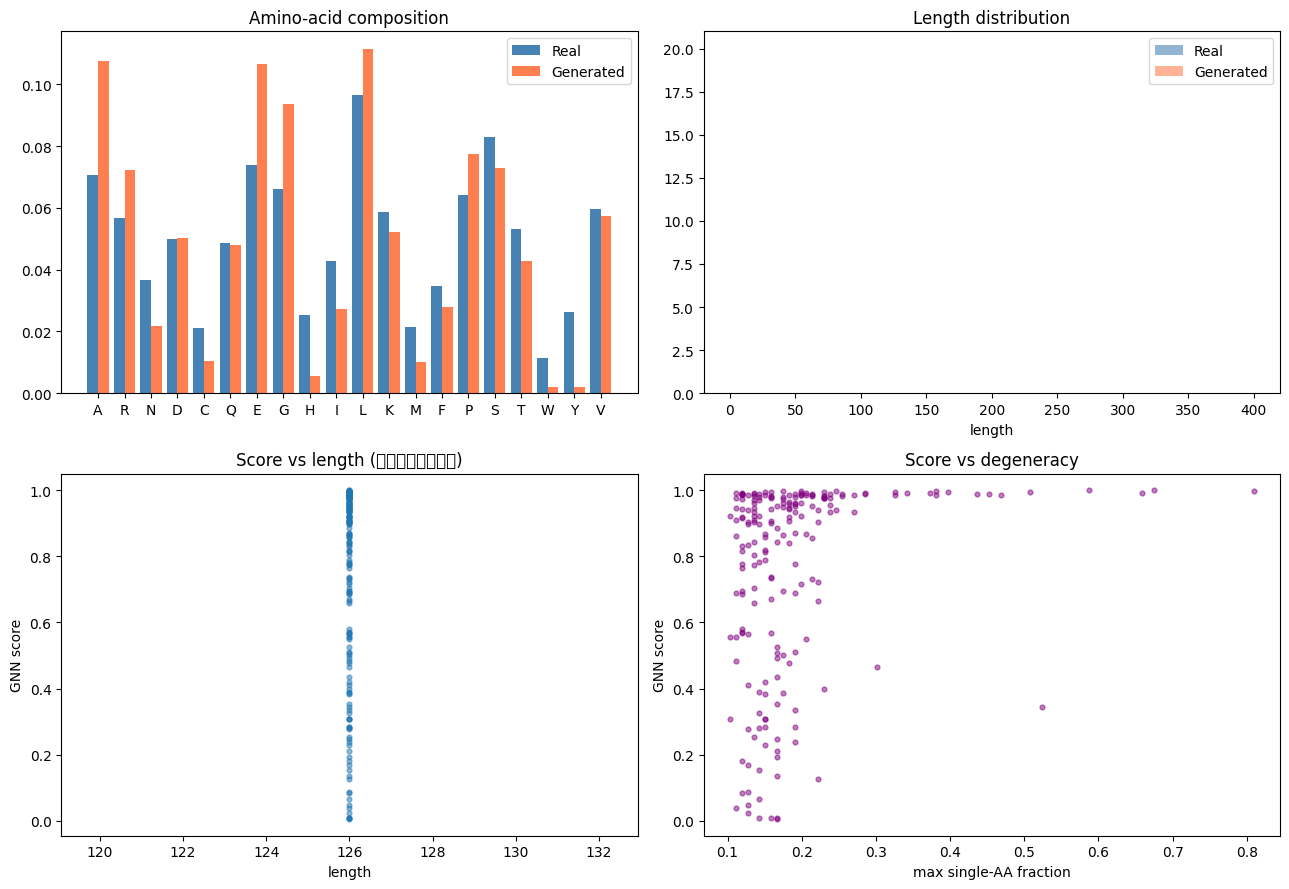


GNN分數 vs 長度     的相關係數: 無法計算 (所有候選長度都一樣，generator 幾乎不輸出 <eos> 停止符)
GNN分數 vs 退化程度 的相關係數: +0.251
(相關係數越接近 0 越好；若很大，代表 GNN 可能只是靠這些表面特徵在給分。)


In [32]:
# =========================================================
# Step 3 — 驗證(一)：候選序列「像不像真蛋白質」的快速體檢 (cheap sanity check)
#   在花大錢跑 ESMFold 之前，先確認生成序列不是退化/亂湊的，
#   並檢查 GNN 分數是不是只是被長度/組成等捷徑帶著走 (reward shortcut)。
# =========================================================
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

AA = list("ARNDCQEGHILKMFPSTWYV")  # 20 種標準胺基酸

def aa_frequency(seqs):
    c, total = Counter(), 0
    for s in seqs:
        c.update(s); total += len(s)
    return np.array([c.get(a, 0) / max(total, 1) for a in AA])

def seq_stats(s):
    cnt = Counter(s); n = len(s)
    distinct = len(cnt)                 # 用到幾種胺基酸 (越多越像真蛋白)
    max_frac = max(cnt.values()) / n    # 單一胺基酸最高占比 (越高越可能退化)
    return distinct, max_frac

def safe_corr(a, b):
    """變異數為 0 (例如所有長度都一樣) 時 corrcoef 會回傳 nan，這裡改回傳 None。"""
    if np.std(a) == 0 or np.std(b) == 0:
        return None
    return float(np.corrcoef(a, b)[0, 1])

# results 來自上一個 cell: list of (rank, score, is_novel, seq)
real_seqs = list(sequence_mapping.keys())
cand_seqs = [r[3] for r in results]
real_freq, gen_freq = aa_frequency(real_seqs), aa_frequency(cand_seqs)

scores   = np.array([r[1] for r in results])
lengths  = np.array([len(r[3]) for r in results])
distinct = np.array([seq_stats(r[3])[0] for r in results])
max_frac = np.array([seq_stats(r[3])[1] for r in results])
real_len = np.array([len(s) for s in real_seqs])

print(f"候選數: {len(results)}")
print(f"長度            : 生成平均 {lengths.mean():.1f}  | 真實蛋白平均 {real_len.mean():.1f}")
print(f"長度的相異值數量: {len(np.unique(lengths))} 種 (若=1 代表全部一樣長，generator 幾乎不輸出 <eos>)")
print(f"用到胺基酸種類  : 平均 {distinct.mean():.1f} / 20")
print(f"單一胺基酸最高占比: 平均 {max_frac.mean():.2f}  (>0.4 通常代表低複雜度/退化)")
print(f"疑似退化序列 (max_frac>0.4): {(max_frac>0.4).sum()} / {len(results)} 條")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
xpos = np.arange(len(AA))
axes[0,0].bar(xpos-0.2, real_freq, width=0.4, label='Real', color='steelblue')
axes[0,0].bar(xpos+0.2, gen_freq,  width=0.4, label='Generated', color='coral')
axes[0,0].set_xticks(xpos); axes[0,0].set_xticklabels(AA)
axes[0,0].set_title('Amino-acid composition'); axes[0,0].legend()

axes[0,1].hist(real_len, bins=40, range=(0,400), alpha=0.6, density=True, label='Real', color='steelblue')
axes[0,1].hist(lengths, bins=20, alpha=0.6, density=True, label='Generated', color='coral')
axes[0,1].set_title('Length distribution'); axes[0,1].set_xlabel('length'); axes[0,1].legend()

axes[1,0].scatter(lengths, scores, s=12, alpha=0.5)
axes[1,0].set_xlabel('length'); axes[1,0].set_ylabel('GNN score'); axes[1,0].set_title('Score vs length (希望沒有明顯趨勢)')

axes[1,1].scatter(max_frac, scores, s=12, alpha=0.5, color='purple')
axes[1,1].set_xlabel('max single-AA fraction'); axes[1,1].set_ylabel('GNN score'); axes[1,1].set_title('Score vs degeneracy')

plt.tight_layout(); plt.show()

c_len = safe_corr(lengths, scores)
c_deg = safe_corr(max_frac, scores)
len_msg = "無法計算 (所有候選長度都一樣，generator 幾乎不輸出 <eos> 停止符)" if c_len is None else f"{c_len:+.3f}"
deg_msg = "無法計算" if c_deg is None else f"{c_deg:+.3f}"
print(f"\nGNN分數 vs 長度     的相關係數: {len_msg}")
print(f"GNN分數 vs 退化程度 的相關係數: {deg_msg}")
print("(相關係數越接近 0 越好；若很大，代表 GNN 可能只是靠這些表面特徵在給分。)")

## Step 3 — 驗證(二)：ESMFold 折疊度 (pLDDT)

候選序列在「組成 / 長度」上已經像真蛋白質了，下一步是結構層級的驗證：把排名最高的候選用 **ESMFold** 預測 3D 結構，並讀取 **pLDDT**（0–100 的每殘基信心分數）。

- **pLDDT > 70**：結構可信，序列「折得起來」，比較像真的蛋白質
- **50–70**：中等，可能是部分折疊或柔性區段
- **< 50**：低信心，可能根本不折疊（低複雜度 / 亂序）

理想的候選是 **GNN 分數高 + pLDDT 高** 兩者兼具——這種才值得再進一步做與 target 的複合物預測（AlphaFold-Multimer）或濕實驗。

> 需要 GPU；`facebook/esmfold_v1` 約 2.8GB，第一次執行會下載。為了省時間與顯存，預設只折前 5 名 (`FOLD_TOP_N`)。

In [33]:
# =========================================================
# Step 3 — 驗證(二)：ESMFold 折疊度檢查 (pLDDT)
#   把排名最高的候選序列預測 3D 結構，用 pLDDT (0~100) 當「可折疊性/信心」分數。
#   pLDDT > 70 大致代表可信的折疊；需要 GPU；模型約 2.8GB (第一次會下載)。
# =========================================================
import torch, os
from transformers import AutoTokenizer, EsmForProteinFolding
from transformers.models.esm.openfold_utils.protein import to_pdb, Protein as OFProtein
from transformers.models.esm.openfold_utils.feats import atom14_to_atom37

# --- 只載入一次模型 (重跑此 cell 不會重複下載) ---
if 'esmfold_model' not in globals():
    print("載入 ESMFold (facebook/esmfold_v1)，第一次會下載約 2.8GB，請稍候...")
    esmfold_tok = AutoTokenizer.from_pretrained("facebook/esmfold_v1")
    esmfold_model = EsmForProteinFolding.from_pretrained("facebook/esmfold_v1", low_cpu_mem_usage=True)
    esmfold_model = esmfold_model.to(device)
    esmfold_model.esm = esmfold_model.esm.half()   # ESM 主幹用半精度省顯存
    esmfold_model.trunk.set_chunk_size(64)         # 分塊計算，降低顯存尖峰
    esmfold_model.eval()
    print("ESMFold 載入完成。")

def convert_outputs_to_pdb(outputs):
    """把 ESMFold 輸出轉成 PDB 字串 (取自 HuggingFace 官方範例)。"""
    final_atom_positions = atom14_to_atom37(outputs["positions"][-1], outputs)
    outputs = {k: v.to("cpu").numpy() for k, v in outputs.items()}
    final_atom_positions = final_atom_positions.cpu().numpy()
    final_atom_mask = outputs["atom37_atom_exists"]
    pdbs = []
    for i in range(outputs["aatype"].shape[0]):
        pred = OFProtein(
            aatype=outputs["aatype"][i],
            atom_positions=final_atom_positions[i],
            atom_mask=final_atom_mask[i],
            residue_index=outputs["residue_index"][i] + 1,
            b_factors=outputs["plddt"][i],
            chain_index=outputs["chain_index"][i] if "chain_index" in outputs else None,
        )
        pdbs.append(to_pdb(pred))
    return pdbs

@torch.no_grad()
def fold_sequence(seq):
    tok = esmfold_tok([seq], return_tensors="pt", add_special_tokens=False)["input_ids"].to(device)
    out = esmfold_model(tok)
    plddt = out["plddt"]                 # [1, L, 37] 每個原子的 pLDDT
    mask  = out["atom37_atom_exists"]    # [1, L, 37] 該原子是否存在
    mean_plddt = float((plddt * mask).sum() / mask.sum())  # 只對實際存在的原子取平均
    # 防呆：某些 transformers/模型版本輸出的 pLDDT 是 0~1 尺度而非標準的 0~100 尺度。
    # 用原始最大值自動偵測並校正，讓後面 >70 / >50 的信心門檻判斷保持有意義。
    if float(plddt.max()) <= 1.5:
        mean_plddt *= 100.0
    pdb_str = convert_outputs_to_pdb(out)[0]
    return mean_plddt, pdb_str

# --- 對排名最高的前 N 條做折疊 ---
FOLD_TOP_N = 5
os.makedirs("folded_pdb", exist_ok=True)

print(f"開始折疊前 {FOLD_TOP_N} 名候選 (target node {TARGET_NODE_ID})...\n")
fold_results = []
for rank, score, is_novel, seq in tqdm(results[:FOLD_TOP_N]):
    mean_plddt, pdb_str = fold_sequence(seq)
    pdb_path = f"folded_pdb/cand{rank}_plddt{mean_plddt:.1f}.pdb"
    with open(pdb_path, "w") as f:
        f.write(pdb_str)
    fold_results.append((rank, score, mean_plddt, is_novel, len(seq), pdb_path))
    tag = "novel" if is_novel else "in_train"
    verdict = "✅ 可信折疊" if mean_plddt > 70 else ("🟡 中等" if mean_plddt > 50 else "❌ 低信心/可能不折疊")
    print(f"#{rank:2d} | GNN={score:.3f} | pLDDT={mean_plddt:5.1f} {verdict} | {tag} | len={len(seq)} -> {pdb_path}")

print("\n=== 摘要 ===")
print(f"{'rank':>4} {'GNN':>6} {'pLDDT':>6} {'len':>4}  novelty")
for rank, score, mean_plddt, is_novel, L, _ in fold_results:
    print(f"{rank:>4} {score:>6.3f} {mean_plddt:>6.1f} {L:>4}  {'novel' if is_novel else 'in_train'}")
print("\nPDB 檔已存到 folded_pdb/，可下載後用 PyMOL/ChimeraX，或上傳到 https://molstar.org/viewer 檢視。")
print("解讀：pLDDT>70 結構可信；同時有 高 GNN 分數 + 高 pLDDT 的候選最值得再做與 target 的複合物預測 (AlphaFold-Multimer)。")

載入 ESMFold (facebook/esmfold_v1)，第一次會下載約 2.8GB，請稍候...


Loading weights: 100%|██████████| 4533/4533 [00:01<00:00, 3779.98it/s]
EsmForProteinFolding LOAD REPORT from: facebook/esmfold_v1
Key                                | Status     | 
-----------------------------------+------------+-
esm.embeddings.position_ids        | UNEXPECTED | 
esm.contact_head.regression.weight | MISSING    | 
esm.contact_head.regression.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESMFold 載入完成。
開始折疊前 5 名候選 (target node 3445)...



 20%|██        | 1/5 [00:01<00:06,  1.60s/it]

# 1 | GNN=1.000 | pLDDT=  0.3 ❌ 低信心/可能不折疊 | novel | len=126 -> folded_pdb/cand1_plddt0.3.pdb


...

# 3 | GNN=0.998 | pLDDT=  0.8 ❌ 低信心/可能不折疊 | novel | len=126 -> folded_pdb/cand3_plddt0.8.pdb


 80%|████████  | 4/5 [00:05<00:01,  1.29s/it]

# 4 | GNN=0.998 | pLDDT=  0.6 ❌ 低信心/可能不折疊 | novel | len=126 -> folded_pdb/cand4_plddt0.6.pdb


100%|██████████| 5/5 [00:06<00:00,  1.29s/it]

# 5 | GNN=0.997 | pLDDT=  0.4 ❌ 低信心/可能不折疊 | novel | len=126 -> folded_pdb/cand5_plddt0.4.pdb

=== 摘要 ===
rank    GNN  pLDDT  len  novelty
   1  1.000    0.3  126  novel
   2  1.000    0.7  126  novel
   3  0.998    0.8  126  novel
   4  0.998    0.6  126  novel
   5  0.997    0.4  126  novel

PDB 檔已存到 folded_pdb/，可下載後用 PyMOL/ChimeraX，或上傳到 https://molstar.org/viewer 檢視。
解讀：pLDDT>70 結構可信；同時有 高 GNN 分數 + 高 pLDDT 的候選最值得再做與 target 的複合物預測 (AlphaFold-Multimer)。


In [34]:
# =========================================================
# 驗證 pLDDT 尺度 + 管線：用「真實蛋白質」當正對照、隨機亂序當負對照
# =========================================================
import random

real_seq = ("MARPHPWWLCVLGTLVGLSATPAPKSCPERHYWAQGKLCCQMCEPGTFLVKDCDQHRKAAQCDPCIPGVSFSPDHHTRPHCESCRHCNSGLLVRN"
            "CTITANAECACRNGWQCRDKECTECDPLPNPSLTARSSQALSPHPQPTHLPYVSEMLEARTAGHMQTLADFRQLPARTLSTHWPPQRSLCSSDFIRIL"
            "VIFSGMFLVFTLAGALFLHQRRKYRSNKGESPVEPAEPCRYSCPREEEGSTIPIQEDYRKPEPACSP")

# 1) 直接看 raw plddt 的範圍 -> 判斷尺度 (0~1 還是 0~100)
tok = esmfold_tok([real_seq], return_tensors="pt", add_special_tokens=False)["input_ids"].to(device)
with torch.no_grad():
    out = esmfold_model(tok)
p = out["plddt"]
print(f"raw plddt  shape={tuple(p.shape)}  min={float(p.min()):.3f}  max={float(p.max()):.3f}  mean={float(p.mean()):.3f}")
print("-> 若 max ≈ 1  代表 0~1 尺度 (需要 ×100)")
print("-> 若 max ≈ 100 代表已經是 0~100 尺度 (我的 ×100 是多餘的)\n")

# 2) 用我們的 fold_sequence (含自動換算) 算正對照
real_plddt, real_pdb = fold_sequence(real_seq)
with open("folded_pdb/REAL_control.pdb", "w") as f:
    f.write(real_pdb)
print(f"真實蛋白質 (正對照) mean_plddt = {real_plddt:5.1f}  (len={len(real_seq)})  -> folded_pdb/REAL_control.pdb")

# 3) 負對照：等長的隨機亂序
random.seed(0)
junk = "".join(random.choice("ARNDCQEGHILKMFPSTWYV") for _ in range(len(real_seq)))
junk_plddt, _ = fold_sequence(junk)
print(f"隨機亂序   (負對照) mean_plddt = {junk_plddt:5.1f}  (len={len(junk)})")

print("\n判讀：")
print("  - 真實蛋白質應該明顯高於隨機亂序 (典型 ~80-90 vs ~30-40)。")
print("  - 若如此 → pLDDT 尺度與 pooling 都正確，前面候選的分數可信。")
print("  - 若真實蛋白也很低 → 是 pooling/尺度的問題，不是序列不好，要回頭修。")

raw plddt  shape=(1, 260, 37)  min=0.269  max=0.981  mean=0.707
-> 若 max ≈ 1  代表 0~1 尺度 (需要 ×100)
-> 若 max ≈ 100 代表已經是 0~100 尺度 (我的 ×100 是多餘的)

真實蛋白質 (正對照) mean_plddt =   0.8  (len=260)  -> folded_pdb/REAL_control.pdb
隨機亂序   (負對照) mean_plddt =   0.2  (len=260)

判讀：
  - 真實蛋白質應該明顯高於隨機亂序 (典型 ~80-90 vs ~30-40)。
  - 若如此 → pLDDT 尺度與 pooling 都正確，前面候選的分數可信。
  - 若真實蛋白也很低 → 是 pooling/尺度的問題，不是序列不好，要回頭修。
